# Use Case 2: Golden Cross Detection - Modelling

## Penjelasan Model

**Golden Cross** adalah pola teknikal di mana **SMA-50 (Simple Moving Average 50 hari)** menyilang **di atas SMA-200**, mengindikasikan potensi tren **bullish** (naik). Sebaliknya, **Death Cross** terjadi saat SMA-50 menyilang di bawah SMA-200, mengindikasikan potensi tren **bearish** (turun).

Pada data cross-sectional ini (snapshot 1 hari untuk 570 saham), kita mengadaptasi konsep Golden Cross menjadi **klasifikasi sinyal pasar**:
- **BULLISH**: Saham dengan perubahan harga positif signifikan (changes_pct > 1%)
- **NEUTRAL**: Perubahan harga kecil (-1% s/d 1%)
- **BEARISH**: Saham dengan perubahan harga negatif signifikan (changes_pct < -1%)

## Algoritma & Flow Eksekusi

```
1. LOAD DATA         -> Membaca CSV transaksi harian IDX
2. PREPROCESSING     -> Handle nilai 0, NaN; bersihkan data
3. FEATURE ENGINEERING:
   a. Price gap (open vs previous close)
   b. Intraday range & volatility indicator
   c. Volume & liquidity ratio
   d. Bid-offer spread & ratio
   e. Price position relative to high/low
4. CREATE TARGET      -> BULLISH/NEUTRAL/BEARISH berdasarkan changes_pct
5. SPLIT DATA         -> 80% train, 20% test (stratified)
6. TRAIN 6 MODEL     -> Random Forest, Gradient Boosting, SVM, KNN, Decision Tree, MLP
7. EVALUATE           -> Accuracy, Precision, Recall, F1-Score, Cross-Validation
8. BEST MODEL         -> Simpan model terbaik
9. VISUALIZE          -> Plot perbandingan model, confusion matrix, distribusi
```

## Library yang Digunakan
- **pandas** - manipulasi data
- **numpy** - operasi numerik
- **matplotlib** - visualisasi
- **scikit-learn** - machine learning (6 algoritma klasifikasi)
- **pickle** - serialisasi model

## 1. Install & Import Library

In [5]:
!pip install pandas numpy matplotlib scikit-learn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score
)

print("Semua library berhasil di-import!")

Semua library berhasil di-import!


## 2. Konfigurasi

- `CSV_PATH`: Path file CSV transaksi harian
- `TEST_SIZE`: Proporsi data test (20%)
- `BULLISH_THRESHOLD`: changes_pct > 1% (sinyal beli / Golden Cross)
- `BEARISH_THRESHOLD`: changes_pct < -1% (sinyal jual / Death Cross)

In [7]:
CSV_PATH = "transaksi_harian_202605251947.csv"
TEST_SIZE = 0.2
RANDOM_STATE = 42
BULLISH_THRESHOLD = 1.0   # %
BEARISH_THRESHOLD = -1.0  # %

print(f"CSV Path    : {CSV_PATH}")
print(f"Test Size   : {TEST_SIZE*100}%")
print(f"Bullish     : changes_pct > {BULLISH_THRESHOLD}%")
print(f"Bearish     : changes_pct < {BEARISH_THRESHOLD}%")

CSV Path    : transaksi_harian_202605251947.csv
Test Size   : 20.0%
Bullish     : changes_pct > 1.0%
Bearish     : changes_pct < -1.0%


## 3. Load Data CSV

Data: `transaksi_harian_202605251947.csv` - snapshot perdagangan harian IDX untuk 570 saham.

Kolom utama:
- `tanggal` - tanggal transaksi
- `kode` - kode saham
- `prev_price` - harga penutupan sebelumnya
- `open_price` - harga pembukaan
- `close_price` - harga penutupan
- `high_price` / `low_price` - harga tertinggi/terendah
- `volume` - volume perdagangan
- `changes_pct` - perubahan harga (%)
- `gap_up_pct` - gap up dari previous close (%)
- dll.

In [8]:
df = pd.read_csv(CSV_PATH, sep=";")
print(f"Data dimuat: {len(df)} baris, {len(df.columns)} kolom")
print(f"Kolom: {list(df.columns)}")
print(f"\nInfo dataset:")
print(f"  Tanggal : {df['tanggal'].unique()}")
print(f"  Jumlah saham : {df['kode'].nunique()}")
print(f"  Null values  : {df.isnull().sum().sum()}")
df.head(10)

Data dimuat: 570 baris, 19 kolom
Kolom: ['tanggal', 'kode', 'prev_price', 'open_price', 'close_price', 'high_price', 'low_price', 'volume', 'frekuensi', 'offer', 'offer_volume', 'bid', 'bid_volume', 'changes_pct', 'high_changes_pct', 'low_changes_pct', 'range_intraday_pct', 'gap_up_pct', 'nilai_transaksi_mil']

Info dataset:
  Tanggal : <StringArray>
['2026-05-22']
Length: 1, dtype: str
  Jumlah saham : 570
  Null values  : 119


,tanggal,kode,prev_price,open_price,close_price,high_price,low_price,volume,frekuensi,offer,offer_volume,bid,bid_volume,changes_pct,high_changes_pct,low_changes_pct,range_intraday_pct,gap_up_pct,nilai_transaksi_mil
0,2026-05-22,aadi,7775,7800,8225,8300,7800,17693200,7364,8250,18000,8225,267400,5.79,6.75,0.32,6.41,0.32,143.20
1,2026-05-22,aali,6525,6500,6600,6675,6275,4181500,3236,6650,4000,6575,20600,1.15,2.30,-3.83,6.15,-0.38,27.29
2,2026-05-22,aces,344,344,348,352,340,25381800,2676,348,14200,346,88700,1.16,2.33,-1.16,3.49,0.00,8.76
3,2026-05-22,acst,83,0,82,83,82,183200,36,83,145300,82,300700,-1.20,0.00,-1.20,NaN,-100.00,0.02
4,2026-05-22,ades,20600,0,20650,20850,20450,20700,48,20625,100,20500,500,0.24,1.21,-0.73,NaN,-100.00,0.43
5,2026-05-22,adhi,175,171,180,180,170,4877500,879,180,88500,179,2500,2.86,2.86,-2.86,5.85,-2.29,0.86
6,2026-05-22,admg,189,189,190,200,183,279300,97,192,11000,188,2500,0.53,5.82,-3.17,8.99,0.00,0.05
7,2026-05-22,admr,1355,1340,1480,1490,1275,46834600,7648,1485,31100,1480,424500,9.23,9.96,-5.90,16.04,-1.11,65.68
8,2026-05-22,adro,2210,2210,2350,2350,2200,54234200,12820,2350,588600,2340,133600,6.33,6.33,-0.45,6.79,0.00,123.65
9,2026-05-22,agar,230,230,228,240,228,35600,36,230,1100,228,25500,-0.87,4.35,-0.87,5.22,0.00,0.01


In [9]:
print("Statistik deskriptif:")
df.describe()

Statistik deskriptif:


,prev_price,open_price,close_price,high_price,low_price,volume,frekuensi,offer,offer_volume,bid,bid_volume,changes_pct,high_changes_pct,low_changes_pct,range_intraday_pct,gap_up_pct,nilai_transaksi_mil
count,570.000000,570.000000,570.000000,570.000000,570.000000,5.700000e+02,570.000000,570.000000,5.700000e+02,570.000000,5.700000e+02,570.000000,570.000000,570.000000,451.000000,570.000000,570.000000
mean,1670.349123,804.550877,1689.831579,1505.708772,1422.919298,3.852453e+07,2420.403509,1531.257895,5.372202e+05,1507.031579,2.145153e+05,1.303684,0.665561,-7.815211,9.525565,-21.473825,21.933053
std,8615.882510,2012.932158,8735.777618,8464.613096,8308.568409,2.996206e+08,7400.354413,8522.625225,5.806769e+06,8466.563813,6.677176e+05,5.259974,19.546868,17.547454,7.000355,40.451670,93.518451
min,61.000000,0.000000,60.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,-14.900000,-100.000000,-100.000000,0.000000,-100.000000,0.000000
25%,151.500000,74.000000,150.000000,141.000000,125.250000,1.720000e+05,83.500000,139.000000,2.400000e+03,136.000000,1.100000e+03,-0.837500,0.512500,-7.140000,4.465000,-6.032500,0.072500
50%,340.000000,198.000000,345.000000,326.000000,298.000000,1.543400e+06,331.500000,322.000000,2.255000e+04,317.000000,1.370000e+04,0.790000,2.340000,-3.740000,7.280000,-0.260000,0.465000
75%,1078.750000,622.500000,1075.000000,993.750000,933.750000,1.202388e+07,1421.500000,1015.000000,1.376000e+05,982.500000,1.326250e+05,3.310000,5.590000,-1.840000,13.540000,0.000000,4.410000
max,190000.000000,24100.000000,193000.000000,193000.000000,189900.000000,6.616733e+09,96276.000000,194000.000000,1.320463e+08,193000.000000,8.318800e+06,25.000000,32.410000,4.350000,40.740000,17.350000,1129.650000


## 4. Preprocessing

- Isi `range_intraday_pct` yang NaN (saham tidak diperdagangkan / open=0) dengan 0
- Isi `open_price=0` (tidak ada pembukaan) dengan `prev_price`
- Hapus baris dengan `volume=0` (saham tidak diperdagangkan sama sekali)

In [10]:
print(f"Data sebelum preprocessing: {len(df)} baris")
print(f"  open_price=0: {(df['open_price'] == 0).sum()} baris")
print(f"  volume=0: {(df['volume'] == 0).sum()} baris")
print(f"  range_intraday_pct NaN: {df['range_intraday_pct'].isna().sum()} baris")

# Isi range_intraday_pct NaN dengan 0
df["range_intraday_pct"] = df["range_intraday_pct"].fillna(0)

# Isi open_price=0 dengan prev_price
df.loc[df["open_price"] == 0, "open_price"] = df.loc[df["open_price"] == 0, "prev_price"]

# Hapus baris dengan volume=0 (saham tidak diperdagangkan)
df = df[df["volume"] > 0].reset_index(drop=True)

print(f"\nData setelah preprocessing: {len(df)} baris")
print(f"  Null values: {df.isnull().sum().sum()}")

Data sebelum preprocessing: 570 baris
  open_price=0: 119 baris
  volume=0: 19 baris
  range_intraday_pct NaN: 119 baris

Data setelah preprocessing: 551 baris
  Null values: 0


## 5. Feature Engineering

Membuat fitur-fitur derivatif yang merepresentasikan sinyal teknikal:

| Fitur | Deskripsi | Interpretasi Golden Cross |
|-------|-----------|--------------------------|
| `gap_pct` | Gap antara open dan previous close | Sinyal pembukaan market |
| `intraday_range_pct` | Range harga intraday / previous | Volatilitas intraday |
| `close_vs_prev_pct` | Close vs previous (sama dengan changes_pct) | Arah tren |
| `close_position` | Posisi close relatif thd high-low | Kekuatan buyer |
| `volume_per_freq` | Volume rata-rata per transaksi | Likuiditas |
| `bid_offer_ratio` | Rasio bid volume / offer volume | Tekanan beli vs jual |
| `price_spread_pct` | Spread bid-offer / mid price | Likuiditas pasar |
| `high_low_range_pct` | (High-Low) / prev_price | Volatilitas |
| `upper_shadow_pct` | (High - max(Close,Open)) / prev | Shadow atas candle |
| `lower_shadow_pct` | (min(Close,Open) - Low) / prev | Shadow bawah candle |
| `body_pct` | Abs(Close-Open) / prev | Body candle |
| `tx_value_log` | Log nilai transaksi | Skala transaksi |
| `is_bullish_candle` | Close > Open (1/0) | Candle positif |
| `high_changes_abs` | Perubahan high dari prev | Jangkauan atas |
| `low_changes_abs` | Perubahan low dari prev | Jangkauan bawah |

In [11]:
# === Price gap & position features ===
df["gap_pct"] = ((df["open_price"] - df["prev_price"]) / df["prev_price"] * 100).clip(-50, 50)
df["close_position"] = (df["close_price"] - df["low_price"]) / (df["high_price"] - df["low_price"] + 1)

# === Candlestick features ===
df["body_pct"] = (abs(df["close_price"] - df["open_price"]) / df["prev_price"] * 100).clip(0, 50)
df["is_bullish_candle"] = (df["close_price"] >= df["open_price"]).astype(int)
df["upper_shadow_pct"] = ((df["high_price"] - df[["close_price", "open_price"]].max(axis=1)) / df["prev_price"] * 100).clip(0, 50)
df["lower_shadow_pct"] = ((df[["close_price", "open_price"]].min(axis=1) - df["low_price"]) / df["prev_price"] * 100).clip(0, 50)
df["high_low_range_pct"] = ((df["high_price"] - df["low_price"]) / df["prev_price"] * 100).clip(0, 100)

# === Volume & liquidity features ===
df["volume_per_freq"] = df["volume"] / (df["frekuensi"] + 1)
df["tx_value_log"] = np.log1p(df["nilai_transaksi_mil"])

# === Bid-Offer features ===
df["bid_offer_ratio"] = df["bid_volume"] / (df["offer_volume"] + 1)
df["price_spread_pct"] = abs(df["offer"] - df["bid"]) / ((df["offer"] + df["bid"]) / 2 + 1) * 100
df["price_spread_pct"] = df["price_spread_pct"].clip(0, 50)

# === Momentum features ===
df["high_changes_abs"] = df["high_changes_pct"].abs()
df["low_changes_abs"] = df["low_changes_pct"].abs()

# Clean infinities
df = df.replace([np.inf, -np.inf], np.nan)

feature_cols = [
    "gap_pct", "close_position", "body_pct", "is_bullish_candle",
    "upper_shadow_pct", "lower_shadow_pct", "high_low_range_pct",
    "volume_per_freq", "tx_value_log",
    "bid_offer_ratio", "price_spread_pct",
    "high_changes_abs", "low_changes_abs",
    "gap_up_pct", "range_intraday_pct",
]

print(f"Fitur yang dibuat ({len(feature_cols)}): ")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")

df[feature_cols].describe()

Fitur yang dibuat (15): 
   1. gap_pct
   2. close_position
   3. body_pct
   4. is_bullish_candle
   5. upper_shadow_pct
   6. lower_shadow_pct
   7. high_low_range_pct
   8. volume_per_freq
   9. tx_value_log
  10. bid_offer_ratio
  11. price_spread_pct
  12. high_changes_abs
  13. low_changes_abs
  14. gap_up_pct
  15. range_intraday_pct


,gap_pct,close_position,body_pct,is_bullish_candle,upper_shadow_pct,lower_shadow_pct,high_low_range_pct,volume_per_freq,tx_value_log,bid_offer_ratio,price_spread_pct,high_changes_abs,low_changes_abs,gap_up_pct,range_intraday_pct
count,551.000000,551.000000,551.000000,551.000000,551.000000,551.000000,551.000000,551.000000,551.000000,5.510000e+02,551.000000,551.000000,551.000000,551.000000,551.000000
mean,-0.617177,0.625837,3.997948,0.700544,1.869972,3.011834,8.773327,7635.322060,1.131941,8.263259e+03,2.133783,4.582849,4.669564,-18.766025,7.796788
std,2.596415,0.289675,4.727723,0.458436,3.358784,2.842637,6.747416,10716.120053,1.518691,1.751174e+05,6.053627,5.407682,3.814398,38.373173,7.321093
min,-14.545455,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,75.000000,0.000000,0.000000e+00,0.107928,0.000000,0.000000,-100.000000,0.000000
25%,-0.675676,0.428571,0.886922,0.000000,0.000000,0.925926,3.946490,1629.485253,0.086178,8.638117e-02,0.588066,0.935000,1.805000,-3.920000,2.455000
50%,0.000000,0.666667,2.319588,1.000000,0.757576,2.362205,6.790123,4358.156028,0.412110,7.989754e-01,0.881057,2.820000,3.600000,0.000000,5.810000
75%,0.000000,0.875000,5.538514,1.000000,2.127660,4.061911,12.422840,9617.050673,1.731654,4.459968e+00,1.571764,5.960000,6.505000,0.000000,11.660000
max,17.346939,0.999678,30.327869,1.000000,25.414365,14.970060,40.740741,106091.368585,7.030548,4.101000e+06,50.000000,32.410000,14.980000,17.350000,40.740000


## 6. Membuat Target Prediksi

Target klasifikasi 3 kelas berdasarkan `changes_pct`:
- **BULLISH (+1)**: changes_pct > 1% (sinyal Golden Cross - naik)
- **NEUTRAL (0)**: changes_pct antara -1% s/d 1%
- **BEARISH (-1)**: changes_pct < -1% (sinyal Death Cross - turun)

Distribusi Target:
  BULLISH :  259 (47.0%)
  NEUTRAL :  163 (29.6%)
  BEARISH :  129 (23.4%)


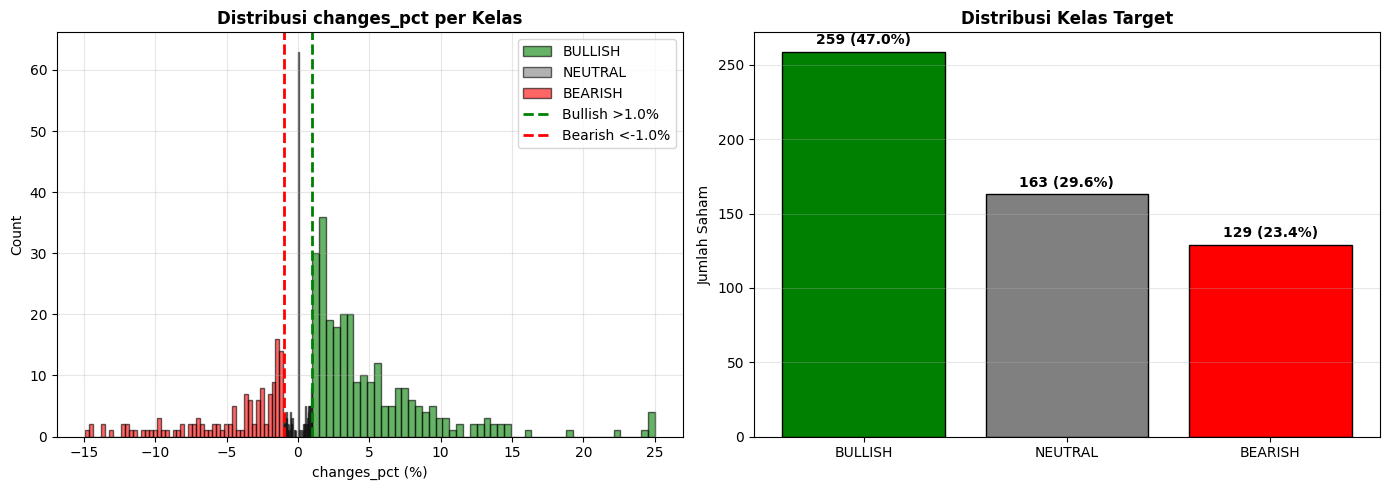

In [12]:
df["target"] = 0
df.loc[df["changes_pct"] > BULLISH_THRESHOLD, "target"] = 1
df.loc[df["changes_pct"] < BEARISH_THRESHOLD, "target"] = -1

label_map = {-1: "BEARISH", 0: "NEUTRAL", 1: "BULLISH"}
df["target_label"] = df["target"].map(label_map)

print("Distribusi Target:")
for label, count in df["target_label"].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {label:8s}: {count:4d} ({pct:.1f}%)")

# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"BULLISH": "green", "NEUTRAL": "gray", "BEARISH": "red"}
ax1 = axes[0]
for label, color in colors.items():
    mask = df["target_label"] == label
    ax1.hist(df.loc[mask, "changes_pct"], bins=50, alpha=0.6, label=label, color=color, edgecolor="black")
ax1.axvline(x=BULLISH_THRESHOLD, color="green", linestyle="--", linewidth=2, label=f"Bullish >{BULLISH_THRESHOLD}%")
ax1.axvline(x=BEARISH_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Bearish <{BEARISH_THRESHOLD}%")
ax1.set_title("Distribusi changes_pct per Kelas", fontweight="bold")
ax1.set_xlabel("changes_pct (%)")
ax1.set_ylabel("Count")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
counts = df["target_label"].value_counts().reindex(["BULLISH", "NEUTRAL", "BEARISH"])
bar_colors = ["green", "gray", "red"]
bars = ax2.bar(counts.index, counts.values, color=bar_colors, edgecolor="black")
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
             f'{val} ({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax2.set_title("Distribusi Kelas Target", fontweight="bold")
ax2.set_ylabel("Jumlah Saham")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 7. Visualisasi Data - EDA (Exploratory Data Analysis)

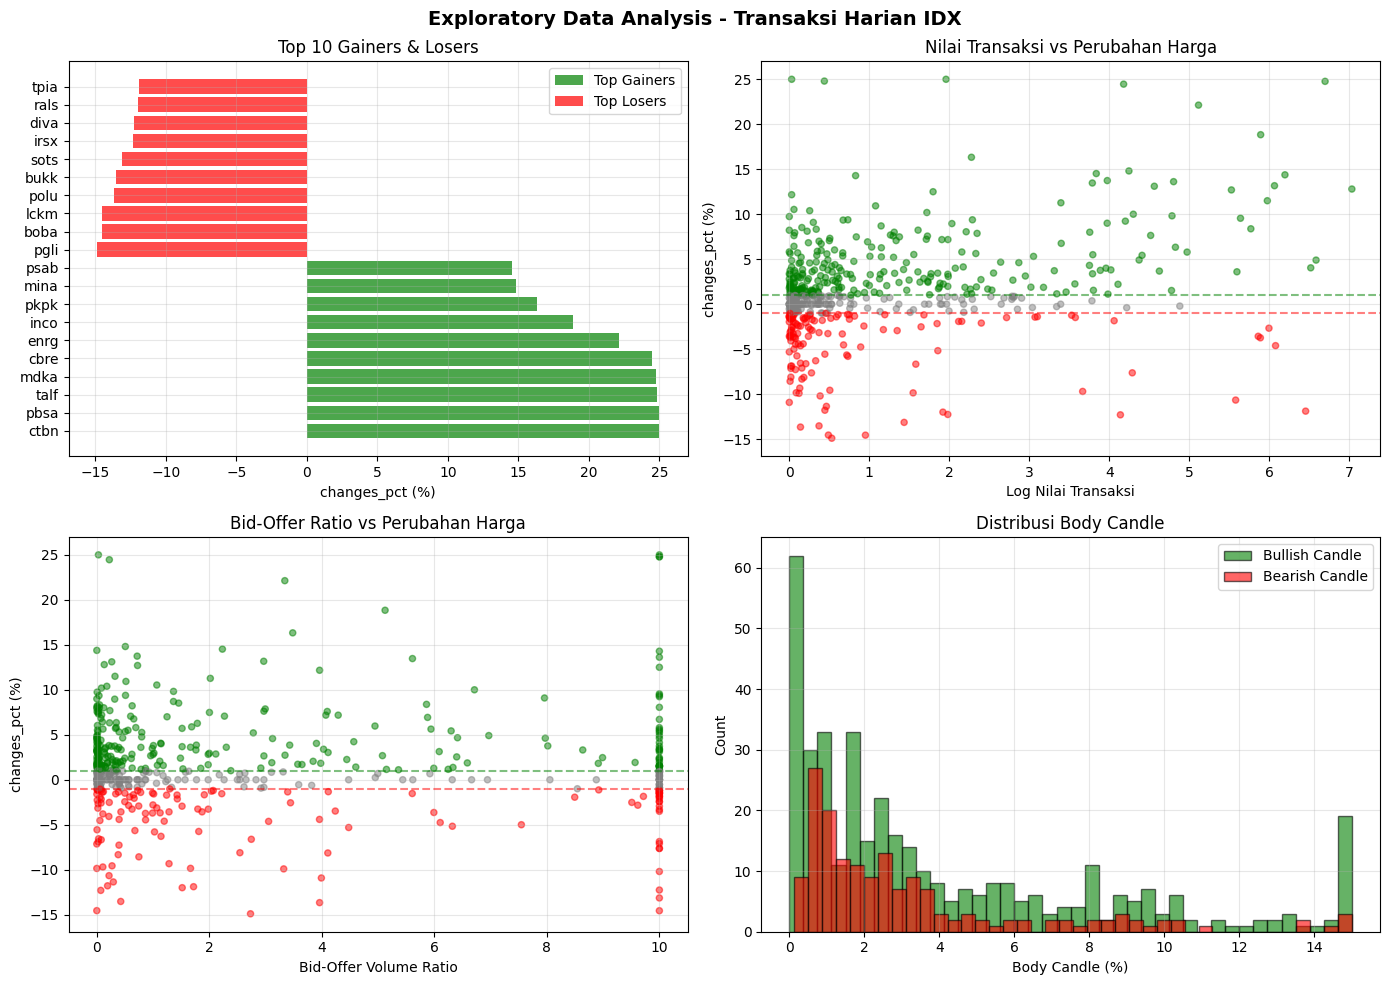

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exploratory Data Analysis - Transaksi Harian IDX", fontsize=14, fontweight="bold")

# Top gainers & losers
ax1 = axes[0, 0]
top10_gain = df.nlargest(10, "changes_pct")[["kode", "changes_pct"]]
top10_loss = df.nsmallest(10, "changes_pct")[["kode", "changes_pct"]]
ax1.barh(top10_gain["kode"], top10_gain["changes_pct"], color="green", alpha=0.7, label="Top Gainers")
ax1.barh(top10_loss["kode"], top10_loss["changes_pct"], color="red", alpha=0.7, label="Top Losers")
ax1.set_xlabel("changes_pct (%)")
ax1.set_title("Top 10 Gainers & Losers")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volume vs changes_pct
ax2 = axes[0, 1]
colors_scatter = df["target"].map({1: "green", 0: "gray", -1: "red"})
ax2.scatter(df["tx_value_log"], df["changes_pct"], c=colors_scatter, alpha=0.5, s=20)
ax2.axhline(y=BULLISH_THRESHOLD, color="green", linestyle="--", alpha=0.5)
ax2.axhline(y=BEARISH_THRESHOLD, color="red", linestyle="--", alpha=0.5)
ax2.set_xlabel("Log Nilai Transaksi")
ax2.set_ylabel("changes_pct (%)")
ax2.set_title("Nilai Transaksi vs Perubahan Harga")
ax2.grid(True, alpha=0.3)

# Bid-Offer ratio vs changes_pct
ax3 = axes[1, 0]
ax3.scatter(df["bid_offer_ratio"].clip(0, 10), df["changes_pct"], c=colors_scatter, alpha=0.5, s=20)
ax3.axhline(y=BULLISH_THRESHOLD, color="green", linestyle="--", alpha=0.5)
ax3.axhline(y=BEARISH_THRESHOLD, color="red", linestyle="--", alpha=0.5)
ax3.set_xlabel("Bid-Offer Volume Ratio")
ax3.set_ylabel("changes_pct (%)")
ax3.set_title("Bid-Offer Ratio vs Perubahan Harga")
ax3.grid(True, alpha=0.3)

# Candlestick feature: body_pct vs changes
ax4 = axes[1, 1]
bullish = df[df["is_bullish_candle"] == 1]
bearish = df[df["is_bullish_candle"] == 0]
ax4.hist(bullish["body_pct"].clip(0, 15), bins=40, alpha=0.6, color="green", label="Bullish Candle", edgecolor="black")
ax4.hist(bearish["body_pct"].clip(0, 15), bins=40, alpha=0.6, color="red", label="Bearish Candle", edgecolor="black")
ax4.set_xlabel("Body Candle (%)")
ax4.set_ylabel("Count")
ax4.set_title("Distribusi Body Candle")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Persiapan Fitur & Split Data

In [14]:
# Hapus baris dengan NaN di fitur
df_clean = df.dropna(subset=feature_cols).reset_index(drop=True)

X = df_clean[feature_cols]
y = df_clean["target"]

print(f"Data siap: {len(df_clean)} sampel, {len(feature_cols)} fitur")
print(f"\nDistribusi kelas:")
for val, label in label_map.items():
    count = (y == val).sum()
    print(f"  {label:8s}: {count} ({count/len(y)*100:.1f}%)")

print(f"\nFitur ({len(feature_cols)}):")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")

Data siap: 551 sampel, 15 fitur

Distribusi kelas:
  BEARISH : 129 (23.4%)
  NEUTRAL : 163 (29.6%)
  BULLISH : 259 (47.0%)

Fitur (15):
   1. gap_pct
   2. close_position
   3. body_pct
   4. is_bullish_candle
   5. upper_shadow_pct
   6. lower_shadow_pct
   7. high_low_range_pct
   8. volume_per_freq
   9. tx_value_log
  10. bid_offer_ratio
  11. price_spread_pct
  12. high_changes_abs
  13. low_changes_abs
  14. gap_up_pct
  15. range_intraday_pct


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {len(X_train)} sampel")
print(f"Testing set : {len(X_test)} sampel")
print(f"\nTraining class distribution:")
for val, label in label_map.items():
    count = (y_train == val).sum()
    print(f"  {label:8s}: {count}")

Training set: 440 sampel
Testing set : 111 sampel

Training class distribution:
  BEARISH : 103
  NEUTRAL : 130
  BULLISH : 207


## 9. Training Model - 6 Algoritma

Kita membandingkan 6 algoritma klasifikasi:

| No | Algoritma | Deskripsi |
|----|-----------|----------|
| 1 | **Random Forest** | Ensemble of decision trees, robust terhadap overfitting |
| 2 | **Gradient Boosting** | Ensemble sequential, fokus pada error sebelumnya |
| 3 | **SVM (RBF)** | Support Vector Machine dengan kernel RBF, cocok untuk non-linear |
| 4 | **KNN (k=5)** | K-Nearest Neighbors, klasifikasi berdasarkan tetangga terdekat |
| 5 | **Decision Tree** | Pohon keputusan tunggal, interpretable |
| 6 | **MLP Neural Net** | Multi-Layer Perceptron dengan 2 hidden layer (64, 32) |

In [16]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", random_state=RANDOM_STATE, class_weight="balanced"),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=RANDOM_STATE),
}

results = {}
best_model_name = None
best_accuracy = 0

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print(f"{'='*50}")
    
    use_scaled = name in ["SVM (RBF)", "KNN (k=5)", "MLP Neural Net"]
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    cv_scores = cross_val_score(model, X_tr, y_train, cv=min(5, len(set(y_train))),
                                scoring="accuracy", n_jobs=-1)
    
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}")
    print(f"  F1-Score    : {f1:.4f}")
    print(f"  CV Accuracy : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    results[name] = {
        "model": model,
        "scaler": scaler,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "y_pred": y_pred,
        "use_scaled": use_scaled,
    }
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name

print(f"\n{'='*60}")
print(f"  BEST MODEL: {best_model_name}")
print(f"  Accuracy  : {best_accuracy:.4f}")
print(f"{'='*60}")


  Training: Random Forest
  Accuracy    : 0.9099
  Precision   : 0.9119
  Recall      : 0.9099
  F1-Score    : 0.9097
  CV Accuracy : 0.8954 (+/- 0.0279)

  Training: Gradient Boosting
  Accuracy    : 0.9189
  Precision   : 0.9196
  Recall      : 0.9189
  F1-Score    : 0.9169
  CV Accuracy : 0.9204 (+/- 0.0228)

  Training: SVM (RBF)
  Accuracy    : 0.8108
  Precision   : 0.8327
  Recall      : 0.8108
  F1-Score    : 0.8160
  CV Accuracy : 0.8000 (+/- 0.0284)

  Training: KNN (k=5)
  Accuracy    : 0.7297
  Precision   : 0.7366
  Recall      : 0.7297
  F1-Score    : 0.7320
  CV Accuracy : 0.7704 (+/- 0.0196)

  Training: Decision Tree
  Accuracy    : 0.9099
  Precision   : 0.9114
  Recall      : 0.9099
  F1-Score    : 0.9095
  CV Accuracy : 0.9045 (+/- 0.0149)

  Training: MLP Neural Net
  Accuracy    : 0.9369
  Precision   : 0.9380
  Recall      : 0.9369
  F1-Score    : 0.9374
  CV Accuracy : 0.9159 (+/- 0.0339)

  BEST MODEL: MLP Neural Net
  Accuracy  : 0.9369


## 10. Evaluasi Detail - Best Model

In [17]:
best = results[best_model_name]
print(f"Model Terbaik: {best_model_name}")
print(f"Accuracy: {best['accuracy']:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, best["y_pred"], 
                            target_names=["BEARISH", "NEUTRAL", "BULLISH"], 
                            zero_division=0))

Model Terbaik: MLP Neural Net
Accuracy: 0.9369

Classification Report:
              precision    recall  f1-score   support

     BEARISH       0.88      0.88      0.88        26
     NEUTRAL       0.88      0.91      0.90        33
     BULLISH       1.00      0.98      0.99        52

    accuracy                           0.94       111
   macro avg       0.92      0.92      0.92       111
weighted avg       0.94      0.94      0.94       111



## 11. Visualisasi Hasil

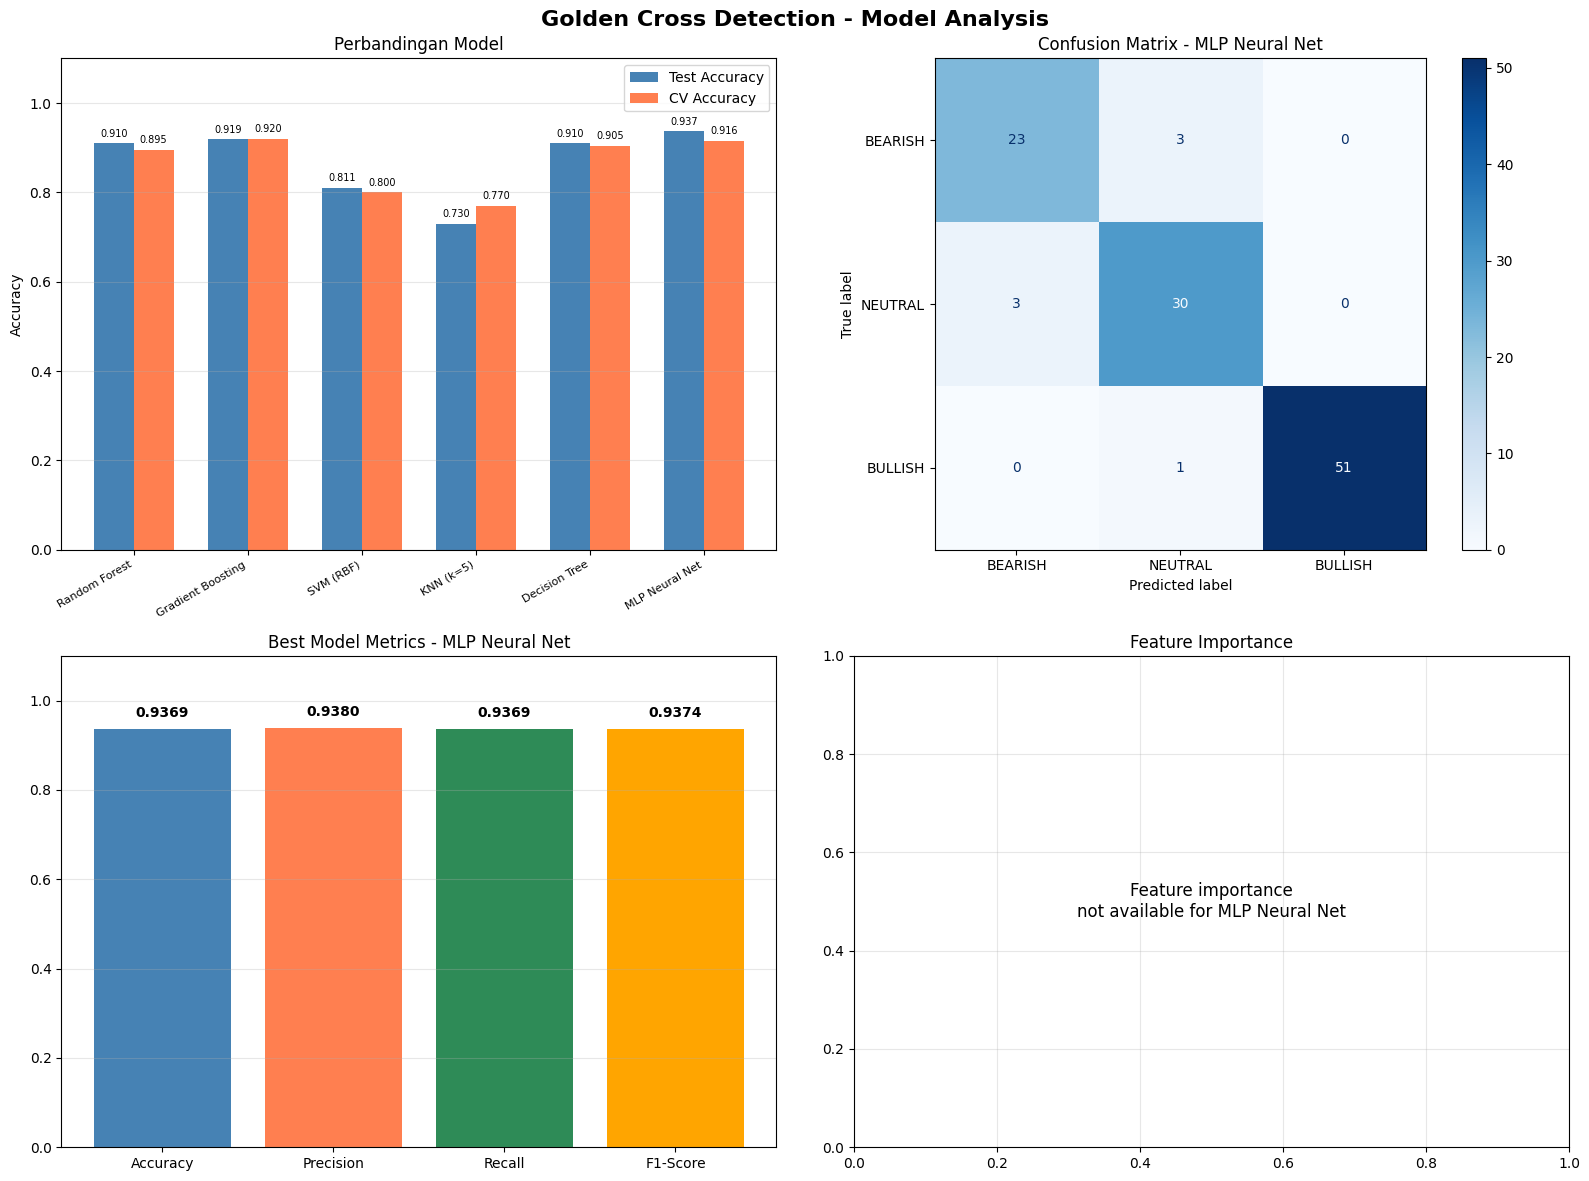

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Golden Cross Detection - Model Analysis", fontsize=16, fontweight="bold")

# Plot 1: Perbandingan Model
ax1 = axes[0, 0]
names = list(results.keys())
accuracies = [results[n]["accuracy"] for n in names]
cv_means = [results[n]["cv_mean"] for n in names]
x_pos = np.arange(len(names))
width = 0.35
bars1 = ax1.bar(x_pos - width/2, accuracies, width, label="Test Accuracy", color="steelblue")
bars2 = ax1.bar(x_pos + width/2, cv_means, width, label="CV Accuracy", color="coral")
ax1.set_ylabel("Accuracy")
ax1.set_title("Perbandingan Model")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")
ax1.set_ylim(0, 1.1)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# Plot 2: Confusion Matrix
ax2 = axes[0, 1]
cm = confusion_matrix(y_test, best["y_pred"], labels=[-1, 0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=["BEARISH", "NEUTRAL", "BULLISH"])
disp.plot(ax=ax2, cmap="Blues")
ax2.set_title(f"Confusion Matrix - {best_model_name}")

# Plot 3: Best Model Metrics
ax3 = axes[1, 0]
metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metrics_vals = [best["accuracy"], best["precision"], best["recall"], best["f1"]]
bars = ax3.bar(metrics_names, metrics_vals, color=["steelblue", "coral", "seagreen", "orange"])
ax3.set_ylim(0, 1.1)
ax3.set_title(f"Best Model Metrics - {best_model_name}")
ax3.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, metrics_vals):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Feature Importance (for tree-based models)
ax4 = axes[1, 1]
if hasattr(best["model"], "feature_importances_"):
    importances = best["model"].feature_importances_
    indices = np.argsort(importances)[::-1]
    ax4.barh(range(len(indices)), importances[indices], color="steelblue")
    ax4.set_yticks(range(len(indices)))
    ax4.set_yticklabels([feature_cols[i] for i in indices], fontsize=8)
    ax4.set_xlabel("Importance")
    ax4.set_title(f"Feature Importance - {best_model_name}")
    ax4.invert_yaxis()
else:
    # Permutation importance or just show coefficients
    ax4.text(0.5, 0.5, f"Feature importance\nnot available for {best_model_name}",
             ha='center', va='center', fontsize=12)
    ax4.set_title("Feature Importance")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("golden_cross_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Ringkasan Perbandingan Seluruh Model

In [19]:
summary_data = []
for name, res in results.items():
    summary_data.append({
        "Model": name,
        "Accuracy": res["accuracy"],
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1-Score": res["f1"],
        "CV Mean": res["cv_mean"],
        "CV Std": res["cv_std"],
    })

df_summary = pd.DataFrame(summary_data).sort_values("Accuracy", ascending=False)
df_summary = df_summary.reset_index(drop=True)
df_summary.index += 1
df_summary.index.name = "Rank"

print("Perbandingan Model (diurutkan berdasarkan Accuracy):\n")
print(df_summary.to_string())
print(f"\nModel Terbaik: {best_model_name} (Accuracy: {best_accuracy:.4f})")

Perbandingan Model (diurutkan berdasarkan Accuracy):

                  Model  Accuracy  Precision    Recall  F1-Score   CV Mean    CV Std
Rank                                                                                
1        MLP Neural Net  0.936937   0.937997  0.936937  0.937364  0.915929  0.033893
2     Gradient Boosting  0.918919   0.919598  0.918919  0.916895  0.920386  0.022775
3         Random Forest  0.909910   0.911867  0.909910  0.909699  0.895365  0.027858
4         Decision Tree  0.909910   0.911446  0.909910  0.909477  0.904513  0.014928
5             SVM (RBF)  0.810811   0.832744  0.810811  0.815996  0.800019  0.028371
6             KNN (k=5)  0.729730   0.736572  0.729730  0.731987  0.770447  0.019582

Model Terbaik: MLP Neural Net (Accuracy: 0.9369)


## 13. Simpan Model

In [20]:
model_data = {
    "model": best["model"],
    "scaler": best["scaler"],
    "feature_cols": feature_cols,
    "model_name": best_model_name,
    "accuracy": best["accuracy"],
    "use_scaled": best["use_scaled"],
    "bullish_threshold": BULLISH_THRESHOLD,
    "bearish_threshold": BEARISH_THRESHOLD,
}

with open("golden_cross_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print(f"Model terbaik disimpan ke 'golden_cross_model.pkl'")
print(f"  Nama Model : {best_model_name}")
print(f"  Accuracy   : {best['accuracy']:.4f}")
print(f"  Fitur      : {len(feature_cols)} fitur")
print(f"  Threshold  : Bullish >{BULLISH_THRESHOLD}%, Bearish <{BEARISH_THRESHOLD}%")

Model terbaik disimpan ke 'golden_cross_model.pkl'
  Nama Model : MLP Neural Net
  Accuracy   : 0.9369
  Fitur      : 15 fitur
  Threshold  : Bullish >1.0%, Bearish <-1.0%


## 14. Prediksi dengan Model

Menampilkan prediksi untuk seluruh saham dan highlight saham dengan sinyal Golden Cross (BULLISH) dan Death Cross (BEARISH).

In [21]:
# Load model
with open("golden_cross_model.pkl", "rb") as f:
    model_data = pickle.load(f)

model = model_data["model"]
scaler = model_data["scaler"]
feat_cols = model_data["feature_cols"]
use_scaled = model_data["use_scaled"]
label_map_inv = {-1: "BEARISH", 0: "NEUTRAL", 1: "BULLISH"}

X_all = df_clean[feat_cols]
if use_scaled:
    X_all_input = scaler.transform(X_all)
else:
    X_all_input = X_all

predictions = model.predict(X_all_input)
df_clean["prediction"] = [label_map_inv.get(p, "UNKNOWN") for p in predictions]

print(f"Model: {model_data['model_name']}")
print(f"Akurasi: {model_data['accuracy']:.4f}")
print(f"\nDistribusi Prediksi:")
for label, count in pd.Series(predictions).value_counts().items():
    print(f"  {label_map_inv.get(label, label)}: {count} ({count/len(predictions)*100:.1f}%)")

# Tampilkan Top BULLISH (Golden Cross signal)
bullish_stocks = df_clean[df_clean["prediction"] == "BULLISH"].nlargest(10, "changes_pct")
print(f"\n{'='*70}")
print(f"  TOP 10 BULLISH (Golden Cross Signal)")
print(f"{'='*70}")
print(bullish_stocks[["kode", "close_price", "changes_pct", "volume", "prediction"]].to_string(index=False))

# Tampilkan Top BEARISH (Death Cross signal)
bearish_stocks = df_clean[df_clean["prediction"] == "BEARISH"].nsmallest(10, "changes_pct")
print(f"\n{'='*70}")
print(f"  TOP 10 BEARISH (Death Cross Signal)")
print(f"{'='*70}")
print(bearish_stocks[["kode", "close_price", "changes_pct", "volume", "prediction"]].to_string(index=False))

Model: MLP Neural Net
Akurasi: 0.9369

Distribusi Prediksi:
  BULLISH: 258 (46.8%)
  NEUTRAL: 164 (29.8%)
  BEARISH: 129 (23.4%)

  TOP 10 BULLISH (Golden Cross Signal)
kode  close_price  changes_pct    volume prediction
ctbn         5750        25.00      6300    BULLISH
pbsa          850        25.00   7476400    BULLISH
talf          780        24.80    762700    BULLISH
mdka         2720        24.77 315769700    BULLISH
cbre          865        24.46  80546500    BULLISH
enrg         1490        22.13 119316200    BULLISH
inco         5550        18.84  68823000    BULLISH
pkpk         2920        16.33   3191100    BULLISH
mina          310        14.81 238055200    BULLISH
psab          426        14.52 110834100    BULLISH

  TOP 10 BEARISH (Death Cross Signal)
kode  close_price  changes_pct    volume prediction
pgli          177       -14.90   3871600    BEARISH
boba          270       -14.56   5666900    BEARISH
lckm          141       -14.55   4466900    BEARISH
polu        

## 15. Penjelasan Algoritma

### Golden Cross Detection Flow (adaptasi untuk data cross-sectional)
```
Data CSV (transaksi_harian IDX)
    |
    v
Preprocessing:
  - Isi open_price=0 dengan prev_price
  - Isi NaN pada range_intraday_pct
  - Hapus baris volume=0
    |
    v
Feature Engineering (15 fitur):
  - gap_pct: gap pembukaan dari previous close
  - close_position: posisi close relatif thd high-low
  - body_pct: body candle
  - is_bullish_candle: candle positif/negatif
  - upper/lower_shadow_pct: shadow candle
  - high_low_range_pct: volatilitas
  - volume_per_freq: likuiditas per transaksi
  - tx_value_log: log nilai transaksi
  - bid_offer_ratio: tekanan beli vs jual
  - price_spread_pct: spread bid-offer
  - high/low_changes_abs: jangkauan harga
  - gap_up_pct, range_intraday_pct
    |
    v
Target Labeling:
  - BULLISH: changes_pct > +1% (sinyal Golden Cross)
  - NEUTRAL: changes_pct -1% s/d +1%
  - BEARISH: changes_pct < -1% (sinyal Death Cross)
    |
    v
Train/Test Split (80/20, stratified)
    |
    v
Train 6 Algoritma ML
    |
    v
Evaluate & Select Best Model
    |
    v
Save Model -> PREDICTION
```

### Hubungan dengan Golden Cross
Pada data time-series, Golden Cross didefinisikan sebagai crossword SMA-50 di atas SMA-200.
Pada data cross-sectional (1 hari, banyak saham), kita mengadaptasi konsep ini:
- **BULLISH** (ekuivalen Golden Cross): Saham dengan momentum positif kuat, bid-offer ratio tinggi, gap up, dan body candle bullish -> prediksi sinyal beli.
- **BEARISH** (ekuivalen Death Cross): Saham dengan momentum negatif, bid-offer ratio rendah, gap down, body candle bearish -> prediksi sinyal jual.

### Alasan Pemilihan Algoritma
1. **Random Forest**: Ensemble berbasis decision tree yang tahan terhadap overfitting, mampu menangkap hubungan non-linear, dan memberikan feature importance.
2. **Gradient Boosting**: Membangun model secara sequential dengan fokus pada error sebelumnya, sering menghasilkan akurasi tinggi.
3. **SVM (RBF)**: Efektif untuk data high-dimensional dengan boundary non-linear.
4. **KNN**: Sederhana dan interpretable, bekerja baik jika pola lokal dominan.
5. **Decision Tree**: Baseline yang interpretable, mudah dipahami.
6. **MLP Neural Net**: Mampu menangkap pola kompleks melalui hidden layer.